<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Connect to the SQLite database


In [2]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [3]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)

   COUNT(*)
0     65437


**Demo 2: List all tables**


In [4]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)

,Table_Name
0,main


**Demo 3: Group data by age**


In [5]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)

                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [6]:
## Write your code here
df_comp = pd.read_sql_query('SELECT CompTotal FROM MAIN', conn)
df_comp

,CompTotal
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
65432,NaN
65433,NaN
65434,NaN
65435,NaN


In [7]:
df_filter = df_comp[df_comp['CompTotal'] < 300000]

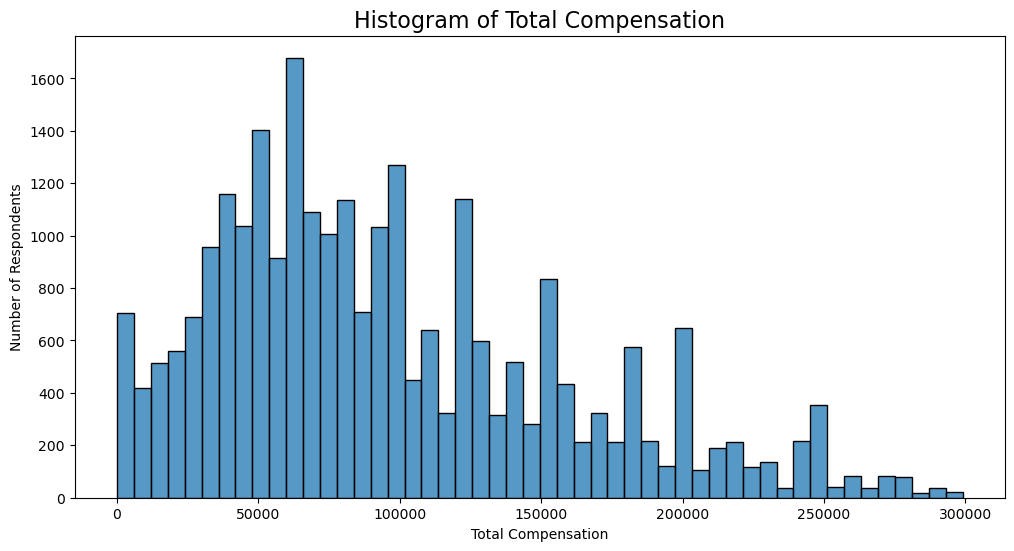

In [8]:
plt.figure(figsize = (12, 6))
sns.histplot(x = df_filter['CompTotal'], bins = 50)
plt.ylabel('Number of Respondents')
plt.xlabel('Total Compensation')
plt.title('Histogram of Total Compensation', fontsize = 16)
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [9]:
## Write your code here
df_ycp = pd.read_sql_query('SELECT YearsCodePro FROM MAIN', conn)
df_ycp

,YearsCodePro
0,None
1,17
2,27
3,None
4,None
...,...
65432,3
65433,None
65434,5
65435,2


In [10]:
df_ycp['YearsCodePro'] = df_ycp['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 55})

In [11]:
df_ycp['YearsCodePro'] = df_ycp['YearsCodePro'].astype(float)

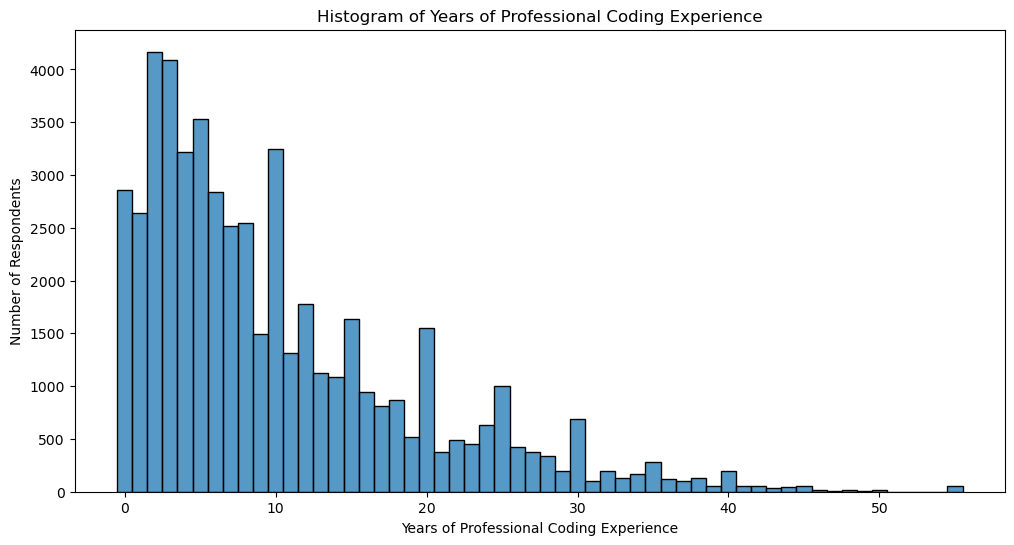

In [12]:
plt.figure(figsize = (12, 6))
sns.histplot(x = df_ycp['YearsCodePro'], discrete = True)
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Number of Respondents')
plt.title('Histogram of Years of Professional Coding Experience')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [13]:
## Write your code here
df_comp_age = pd.read_sql_query('SELECT CompTotal, Age FROM MAIN WHERE CompTotal <= 300000', conn)
df_comp_age

,CompTotal,Age
0,28000.0,25-34 years old
1,85000.0,35-44 years old
2,50000.0,35-44 years old
3,110000.0,25-34 years old
4,126420.0,35-44 years old
...,...,...
26214,36000.0,18-24 years old
26215,40000.0,25-34 years old
26216,61000.0,25-34 years old
26217,58000.0,35-44 years old


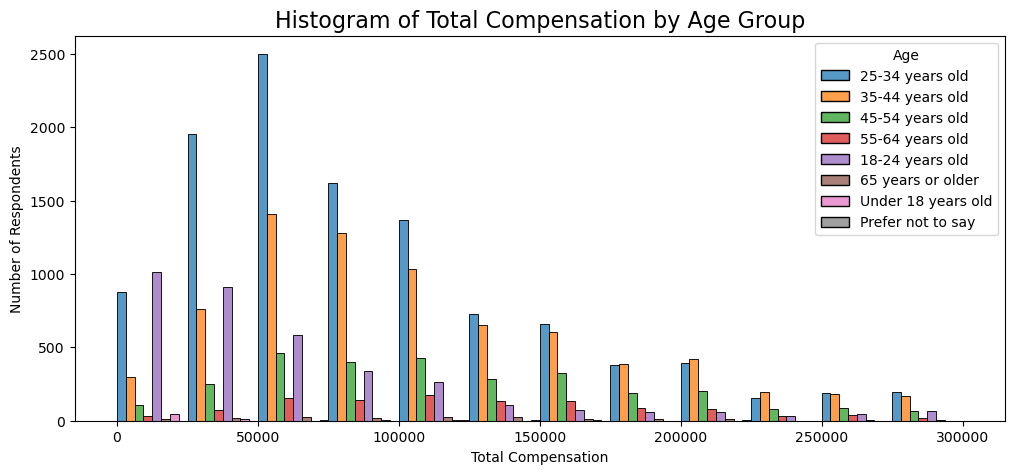

In [14]:
plt.figure(figsize = (12, 5))
sns.histplot(data = df_comp_age, x = 'CompTotal', hue = 'Age', binwidth = 25000, multiple = 'dodge')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.title('Histogram of Total Compensation by Age Group', fontsize = 16)
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [15]:
## Write your code here
df_tsear_age = pd.read_sql_query('SELECT Age, TimeSearching FROM MAIN', conn)
df_tsear_age

,Age,TimeSearching
0,Under 18 years old,None
1,35-44 years old,None
2,45-54 years old,None
3,18-24 years old,None
4,18-24 years old,None
...,...,...
65432,18-24 years old,None
65433,25-34 years old,None
65434,25-34 years old,None
65435,18-24 years old,None


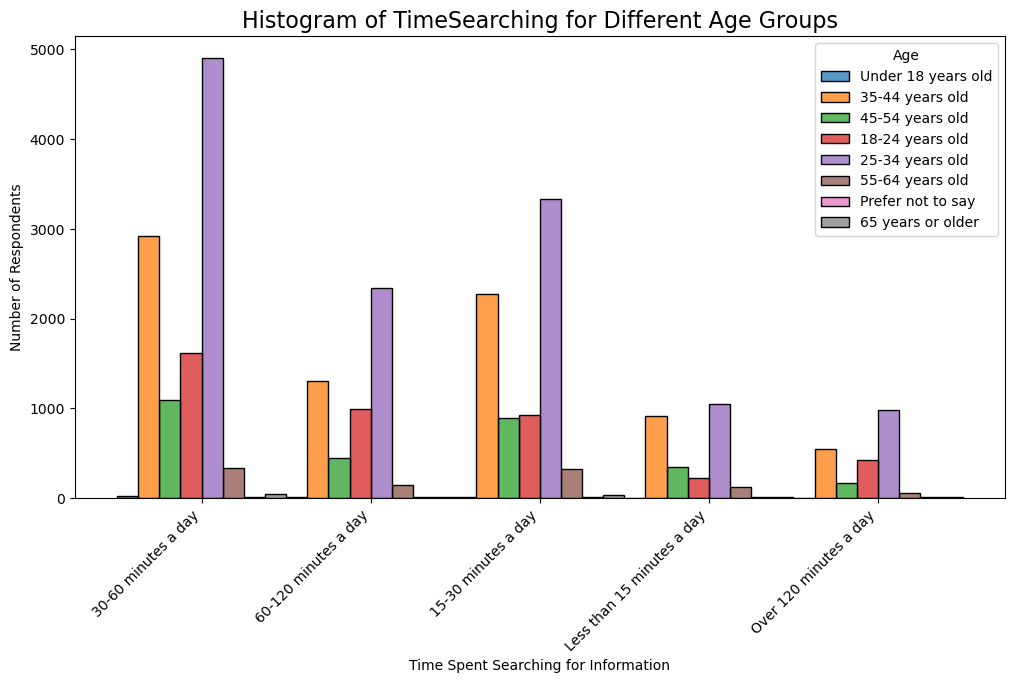

In [16]:
plt.figure(figsize = (12, 6))
sns.histplot(data = df_tsear_age, x = 'TimeSearching', hue = 'Age', multiple = 'dodge')
plt.xlabel('Time Spent Searching for Information')
plt.ylabel('Number of Respondents')
plt.title('Histogram of TimeSearching for Different Age Groups', fontsize = 16)
plt.xticks(rotation = 45, ha = 'right')
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [17]:
df_raw = pd.read_sql_query('SELECT DatabaseWantToWorkWith FROM MAIN WHERE DatabaseWantToWorkWith IS NOT NULL', conn)
df_raw

,DatabaseWantToWorkWith
0,PostgreSQL
1,Firebase Realtime Database
2,MongoDB;MySQL;PostgreSQL
3,PostgreSQL;SQLite
4,Cloud Firestore
...,...
42553,Dynamodb
42554,BigQuery;Cassandra;Databricks SQL;DuckDB;Elast...
42555,Elasticsearch;PostgreSQL;Redis
42556,PostgreSQL;SQLite


In [18]:
top_5 = df_raw['DatabaseWantToWorkWith'].value_counts().nlargest(5).index
top_5

Index(['PostgreSQL', 'PostgreSQL;SQLite', 'SQLite', 'Microsoft SQL Server',
       'MySQL'],
      dtype='object', name='DatabaseWantToWorkWith')

In [19]:
df_top5 = df_raw[df_raw['DatabaseWantToWorkWith'].isin(top_5)]
df_top5

,DatabaseWantToWorkWith
0,PostgreSQL
3,PostgreSQL;SQLite
9,MySQL
11,Microsoft SQL Server
13,Microsoft SQL Server
...,...
42526,PostgreSQL
42535,PostgreSQL
42537,SQLite
42544,PostgreSQL


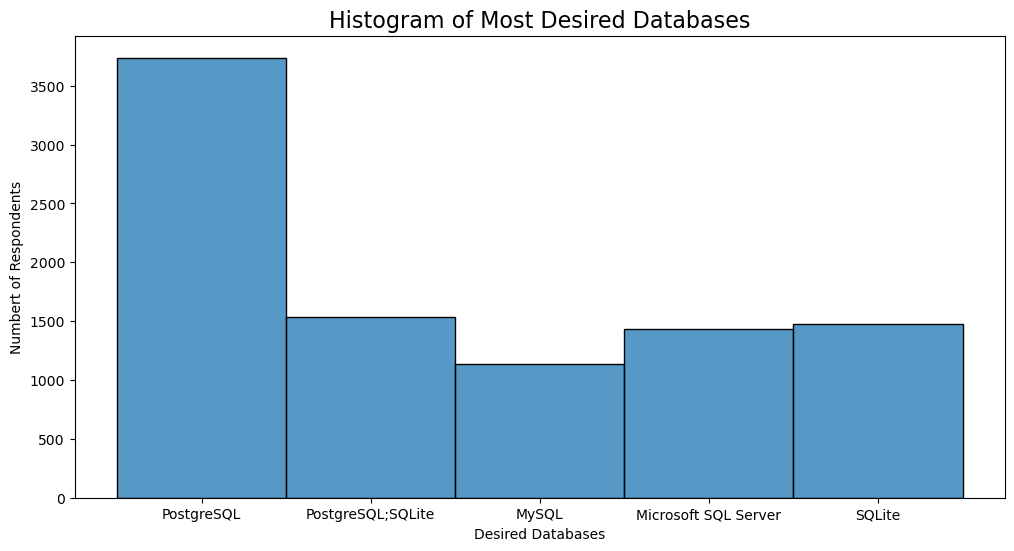

In [20]:
plt.figure(figsize = (12, 6))
sns.histplot(data = df_top5, x = 'DatabaseWantToWorkWith')
plt.xlabel('Desired Databases')
plt.ylabel('Numbert of Respondents')
plt.title('Histogram of Most Desired Databases', fontsize = 16)
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [21]:
## Write your code here
df_re = pd.read_sql_query('SELECT RemoteWork FROM MAIN', conn)
df_re

,RemoteWork
0,Remote
1,Remote
2,Remote
3,None
4,None
...,...
65432,Remote
65433,Remote
65434,In-person
65435,"Hybrid (some remote, some in-person)"


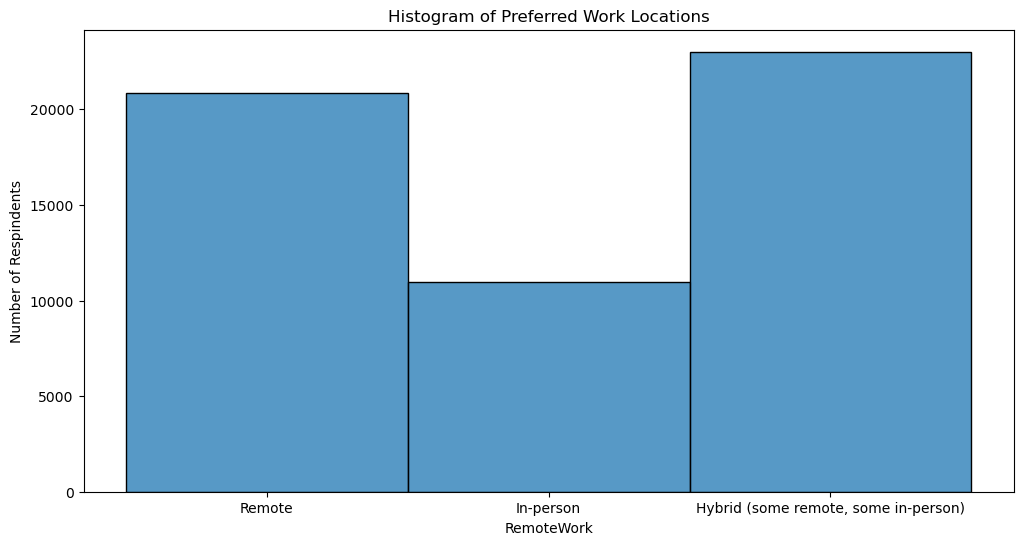

In [22]:
plt.figure(figsize = (12, 6))
sns.histplot(data = df_re, x = 'RemoteWork')
plt.ylabel('Number of Respindents')
plt.title('Histogram of Preferred Work Locations')
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [23]:
## Write your code here
df_comp_age2 = pd.read_sql_query('SELECT CompTotal, Age FROM MAIN WHERE Age IN ("45-54 years old", "55-64 years old") AND CompTotal IS NOT NULL', conn)
df_comp_age2

,CompTotal,Age
0,95000.0,45-54 years old
1,195000.0,45-54 years old
2,54000.0,55-64 years old
3,145000.0,45-54 years old
4,80000.0,55-64 years old
...,...,...
4790,40000.0,45-54 years old
4791,250000.0,45-54 years old
4792,250000.0,45-54 years old
4793,157000.0,45-54 years old


In [24]:
upper = df_comp_age2['CompTotal'].quantile(0.95)
df_ca = df_comp_age2[df_comp_age2['CompTotal'] <= upper]
df_ca

,CompTotal,Age
0,95000.0,45-54 years old
1,195000.0,45-54 years old
2,54000.0,55-64 years old
3,145000.0,45-54 years old
4,80000.0,55-64 years old
...,...,...
4790,40000.0,45-54 years old
4791,250000.0,45-54 years old
4792,250000.0,45-54 years old
4793,157000.0,45-54 years old


In [25]:
med = df_ca['CompTotal'].median()

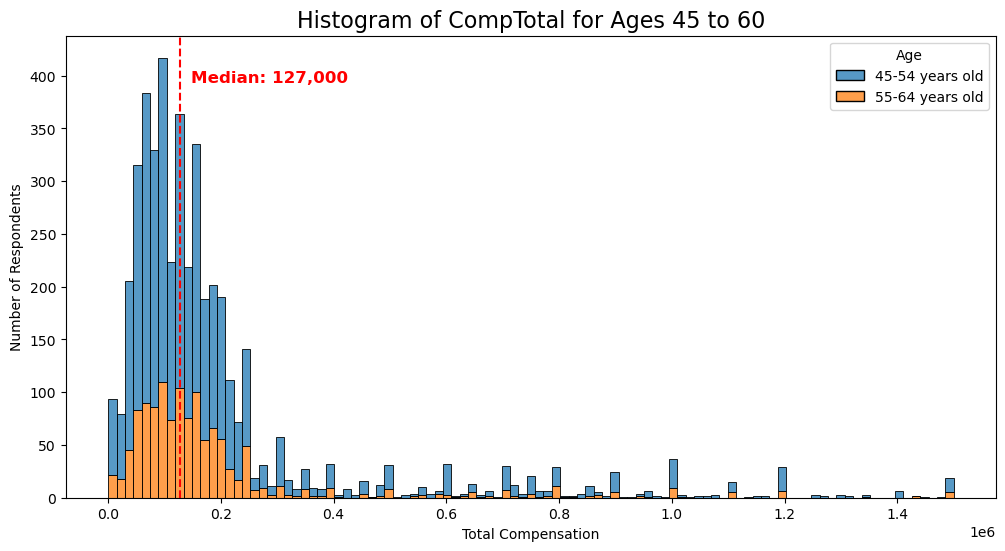

In [26]:
plt.figure(figsize = (12, 6))
sns.histplot(data = df_ca, x = 'CompTotal', hue = 'Age', multiple = 'stack')
plt.axvline(med, color = 'red', linestyle = '--')
y_pos = plt.ylim()[1] * 0.90
x_pos = med + 20000
plt.text(x_pos, y_pos, f'Median: {med:,.0f}', color='red', fontsize=12, fontweight='bold')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.title('Histogram of CompTotal for Ages 45 to 60', fontsize = 16)
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [27]:
## Write your code here
df_js_ycp = pd.read_sql_query('SELECT JobSat, YearsCodePro FROM MAIN WHERE JobSat IS NOT NULL AND YearsCodePro IS NOT NULL', conn)
df_js_ycp

,JobSat,YearsCodePro
0,8.0,12
1,5.0,27
2,10.0,10
3,6.0,Less than 1 year
4,9.0,18
...,...,...
28351,8.0,17
28352,5.0,10
28353,8.0,2
28354,8.0,7


In [28]:
df_js_ycp['YearsCodePro'] = df_js_ycp['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 55})

In [29]:
df_js_ycp['YearsCodePro'] = df_js_ycp['YearsCodePro'].astype(float)

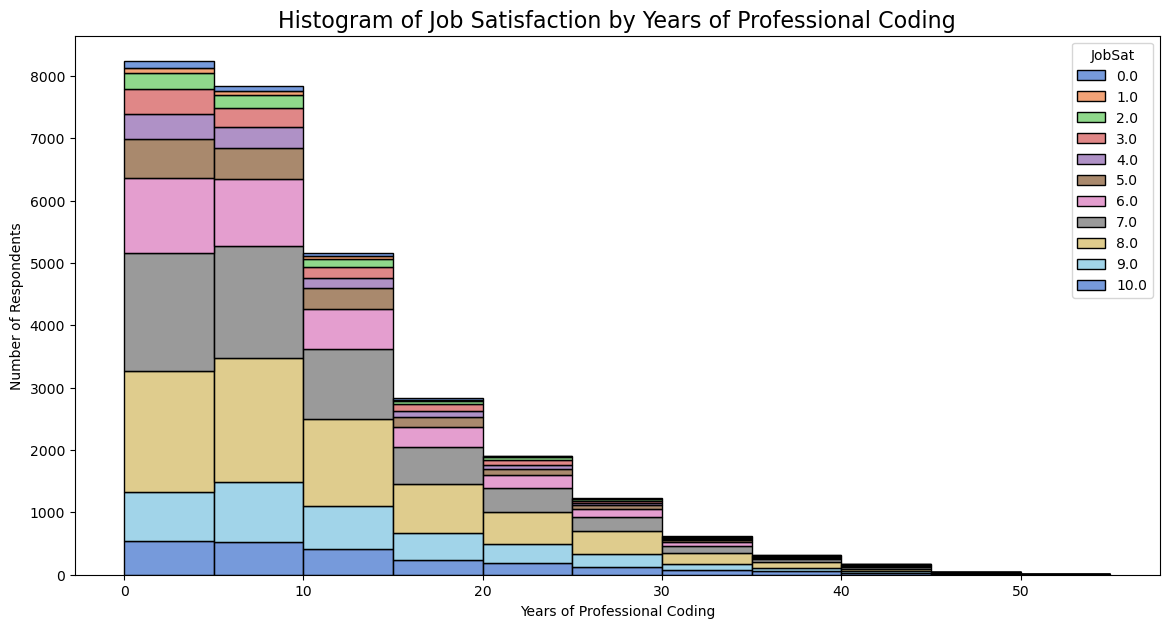

In [30]:
plt.figure(figsize=(14, 7))
sns.histplot(data = df_js_ycp, x = 'YearsCodePro', hue = 'JobSat', multiple = 'stack', palette = 'muted', binwidth = 5)
plt.xlabel('Years of Professional Coding')
plt.ylabel('Number of Respondents')
plt.title('Histogram of Job Satisfaction by Years of Professional Coding', fontsize=16)
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [31]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
